<a href="https://colab.research.google.com/github/mfarias76/MVP_PUCRJ_Sprint1_MachineLearning/blob/main/MVP_Analise_Dados_Boas_Praticas_Sprint3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP - Análise de Dados e Boas Práticas

**Nome:** Mario Henrique Botelho Farias

**Matrícula:** 4052025001116

**Dataset:** [Índice FipeZap a partir de 2008 Dataset](https://www.kaggle.com/datasets/ricardoalvesgomes/fipezapsp-012008-022021)

Usada a fonte de dados "FipeZapTOTAL_2008-01_2026-01.csv"


# Descrição do Problema

O conjunto de dados FipeZap é um dataset de série temporal que apresenta a evolução dos preços médios de venda e aluguel de imóveis no Brasil ao longo do tempo. Sendo o objetivo principal analisar como os preços e a rentabilidade dos imóveis evoluíram, identificando padrões, tendências e relações entre as variáveis.

#Hipóteses do Problema

As hipóteses levantadas são:

* Os preços de venda e aluguel apresentam tendência de crescimento ao longo do tempo?

* Existe correlação entre o preço de venda e o preço de aluguel?

* A rentabilidade dos aluguéis acompanha o crescimento dos preços?

# Tipo de Problema

Este é um problema de análise supervisionada com foco em regressão e análise exploratória, a partir de um conjunto de variáveis ao longo do tempo, onde o objetivo é compreender e modelar valores numéricos, como preço e rentabilidade.

# Seleção de Dados

O dataset utilizado foi obtido a partir do índice FipeZap, amplamente utilizado para análise do mercado imobiliário brasileiro, e os dados já se encontram estruturados, sendo necessário apenas tratamento e preparação para análise.

# Atributos do Dataset

O dataset contém observações mensais ao longo de vários anos, com os seguintes atributos principais:

* Data: período da observação;

* Preço médio de vendas (R$/m²): valor médio de venda dos imóveis;

* Preço médio de aluguéis (R$/m²): valor médio de aluguel;

* Rentabilidade: retorno percentual do aluguel;

* Variação mensal: variação percentual dos preços;

# Importação e Carga de Dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar dataset
df = pd.read_csv('/content/FipeZapTOTAL_2008-01_2026-01.csv')

# Converter coluna de data
df['Data'] = pd.to_datetime(df['Data'])

# Ordenar
df = df.sort_values('Data')

df.head()

,Data,Indice de vendas residenciais,Variacao mensal de vendas residenciais,Preco medio de vendas residenciais (RS/m2),Indice de alugueis residenciais,Variacao mensal de alugueis residenciais,Preco medio de alugueis residenciais (RS/m2),Rentabilidade dos alugueis residenciais,Indice de vendas comerciais,Variacao mensal de vendas comerciais,Preco medio de vendas comerciais (RS/m2),Indice de alugueis comerciais,Variacao mensal de alugueis comerciais,Preco medio de alugueis comerciais (RS/m2),Rentabilidade dos alugueis comerciais
0,2008-01-01,41.811068,NaN,2226.191929,70.866823,NaN,13.207832,0.006444,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2008-02-01,42.065077,0.006075,2239.716379,71.552871,0.009681,13.335695,0.006484,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2008-03-01,42.506114,0.010485,2263.199014,74.228603,0.037395,13.834385,0.006655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2008-04-01,43.090377,0.013745,2294.307529,75.434471,0.016245,14.059130,0.006688,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2008-05-01,43.666822,0.013378,2324.999839,77.130437,0.022483,14.375216,0.006753,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Análise de Dados

Nesta etapa de Análise Exploratória (EDA), busca-se entender a evolução temporal dos preços, sua distribuição e as relações entre as variáveis.

# Estrutura dos dados

In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   Data                                          215 non-null    datetime64[ns]
 1   Indice de vendas residenciais                 215 non-null    float64       
 2   Variacao mensal de vendas residenciais        214 non-null    float64       
 3   Preco medio de vendas residenciais (RS/m2)    215 non-null    float64       
 4   Indice de alugueis residenciais               215 non-null    float64       
 5   Variacao mensal de alugueis residenciais      214 non-null    float64       
 6   Preco medio de alugueis residenciais (RS/m2)  215 non-null    float64       
 7   Rentabilidade dos alugueis residenciais       215 non-null    float64       
 8   Indice de vendas comerciais                   167 non-null    float64 

,0
Data,0
Indice de vendas residenciais,0
Variacao mensal de vendas residenciais,1
Preco medio de vendas residenciais (RS/m2),0
Indice de alugueis residenciais,0
Variacao mensal de alugueis residenciais,1
Preco medio de alugueis residenciais (RS/m2),0
Rentabilidade dos alugueis residenciais,0
Indice de vendas comerciais,48
Variacao mensal de vendas comerciais,49


# Análise Inicial



* Dados temporais

  Trata-se de uma série temporal com observações mensais, o que possibilita identificar tendências, padrões e ciclos no comportamento do mercado imobiliário ao longo do período analisado.
  
* Valores faltantes

  Observou-se a presença de valores faltantes em algumas variáveis, principalmente nos períodos iniciais da série temporal, o que é comum em dados históricos consolidados ao longo do tempo. Esses valores foram tratados utilizando técnicas adequadas para séries temporais, garantindo a continuidade e consistência dos dados.

# Evolução dos preços

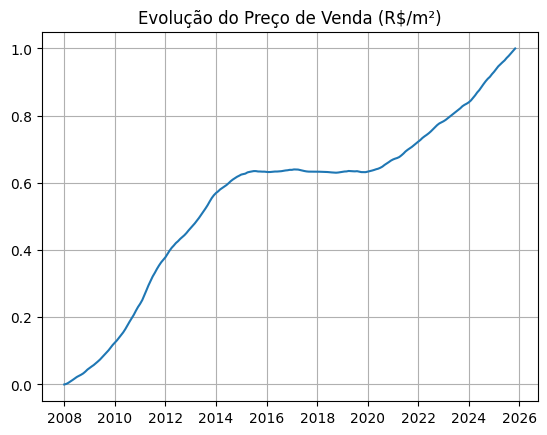

In [ ]:
plt.figure()
plt.plot(df['Data'], df['Preco medio de vendas residenciais (RS/m2)'])
plt.title('Evolução do Preço de Venda (R$/m²)')
plt.grid()
plt.show()

Observa-se uma tendência de crescimento ao longo do tempo, com períodos de desaceleração.

# Tendência Real

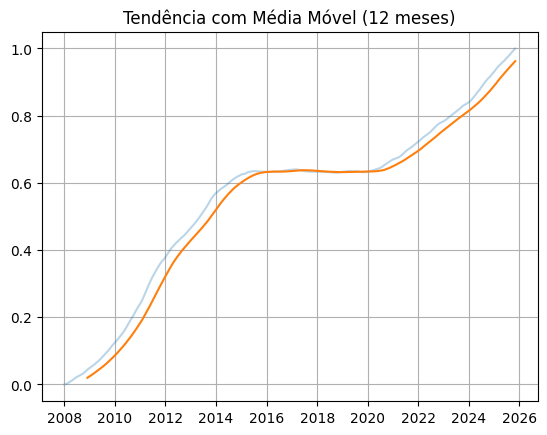

In [ ]:
df['media_movel'] = df[
    'Preco medio de vendas residenciais (RS/m2)'
].rolling(12).mean()

plt.plot(df['Data'], df['Preco medio de vendas residenciais (RS/m2)'], alpha=0.3)
plt.plot(df['Data'], df['media_movel'])

plt.title('Tendência com Média Móvel (12 meses)')
plt.grid()
plt.show()

A média móvel suaviza oscilações e evidencia a tendência de longo prazo do mercado.

# Comparação Venda vs Aluguel

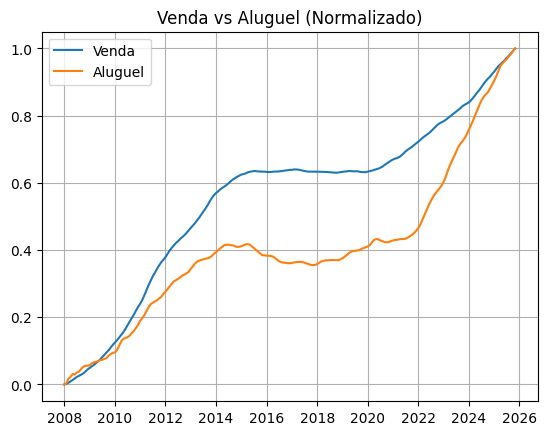

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['venda_norm', 'aluguel_norm']] = scaler.fit_transform(df[[
    'Preco medio de vendas residenciais (RS/m2)',
    'Preco medio de alugueis residenciais (RS/m2)'
]])

plt.plot(df['Data'], df['venda_norm'], label='Venda')
plt.plot(df['Data'], df['aluguel_norm'], label='Aluguel')

plt.legend()
plt.title('Venda vs Aluguel (Normalizado)')
plt.grid()
plt.show()

A normalização permite comparar as tendências, mostrando que venda e aluguel crescem de forma semelhante.

# Boxplot por ano

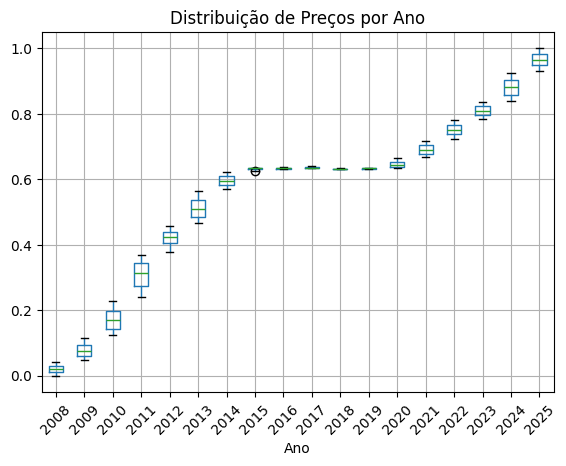

In [ ]:
df['Ano'] = df['Data'].dt.year

df.boxplot(column='Preco medio de vendas residenciais (RS/m2)', by='Ano')

plt.title('Distribuição de Preços por Ano')
plt.suptitle('')
plt.xticks(rotation=45)
plt.show()

O boxplot permite observar a dispersão dos preços e identificar possíveis outliers ao longo dos anos.

# Rentabilidade

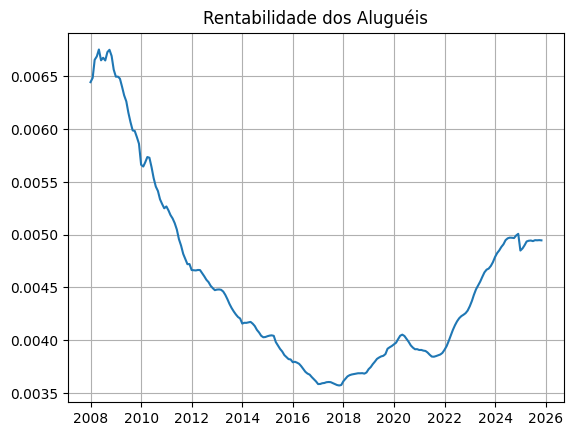

In [ ]:
plt.plot(df['Data'], df['Rentabilidade dos alugueis residenciais'])

plt.title('Rentabilidade dos Aluguéis')
plt.grid()
plt.show()

A rentabilidade apresenta oscilações e não acompanha diretamente o crescimento dos preços.

# Crescimento Real

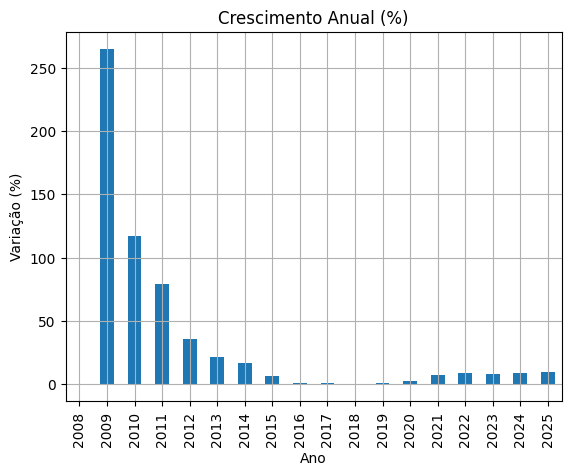

In [ ]:
media_anual = df.groupby(df['Data'].dt.year)[col].mean()

crescimento_anual = media_anual.pct_change() * 100

crescimento_anual.plot(kind='bar')

plt.title('Crescimento Anual (%)')
plt.xlabel('Ano')
plt.ylabel('Variação (%)')
plt.grid()

plt.show()

O gráfico mostra a variação percentual ano a ano, evidenciando períodos de crescimento e retração.

# Correlação

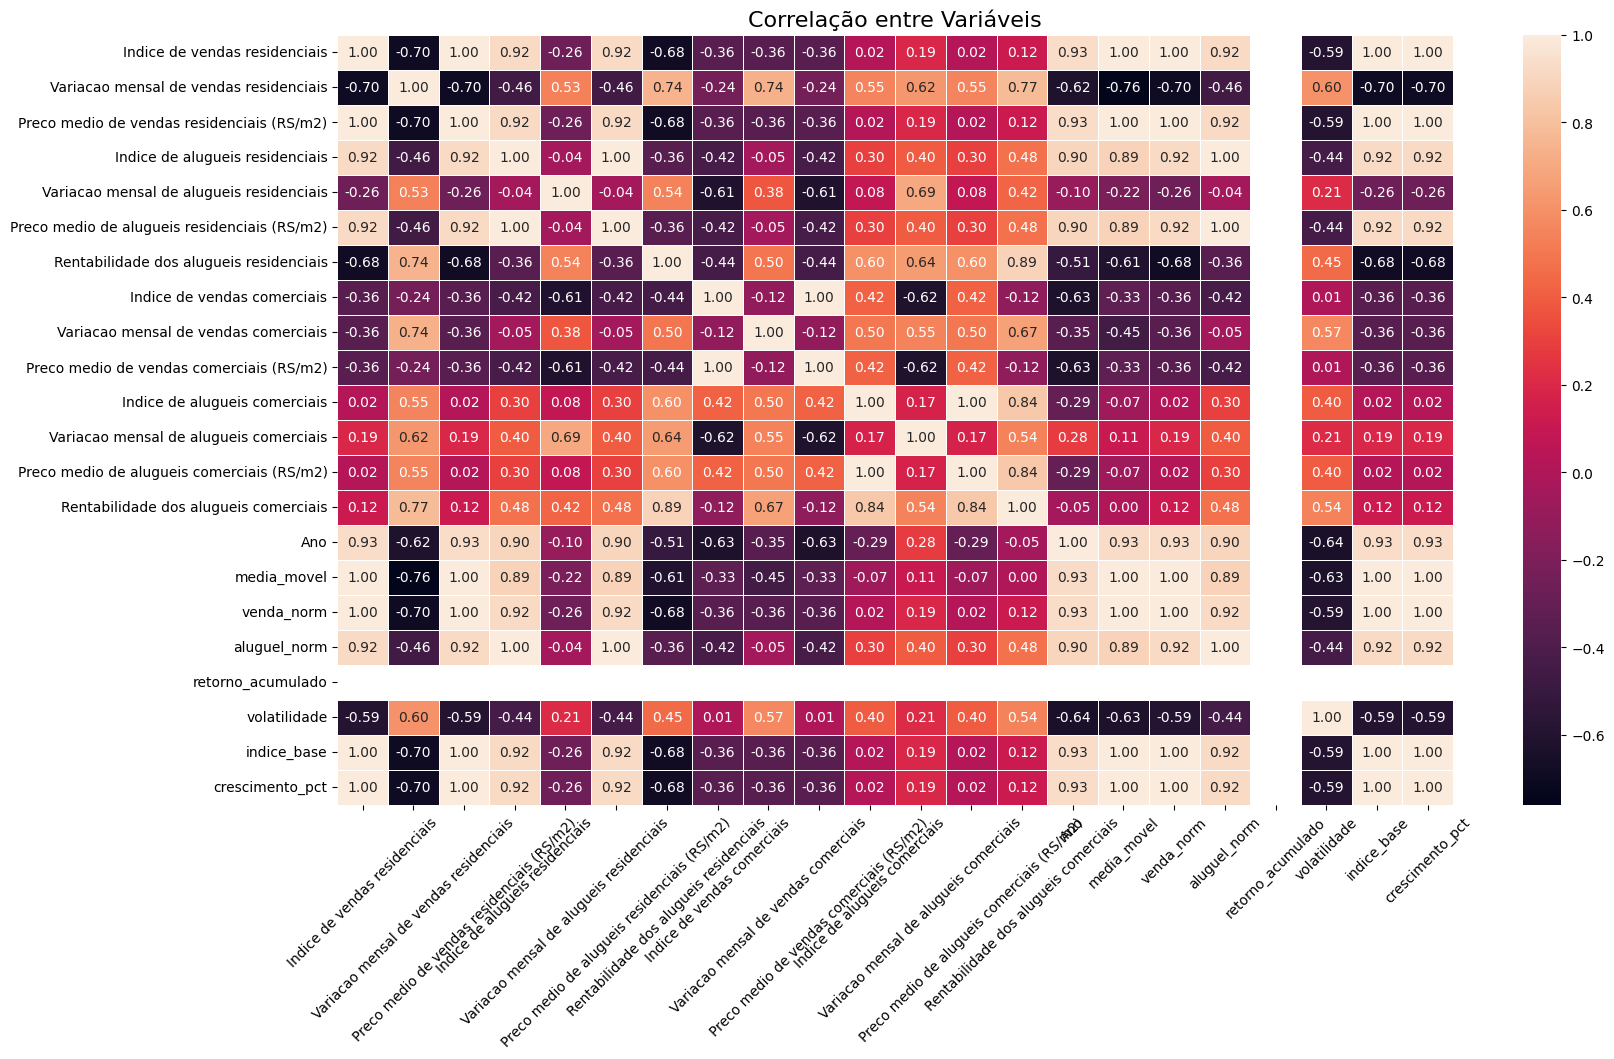

In [ ]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(18, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10},
    linewidths=0.5
)

plt.title('Correlação entre Variáveis', fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

Observa-se forte correlação entre os preços de venda e aluguel.

# Volatilidade

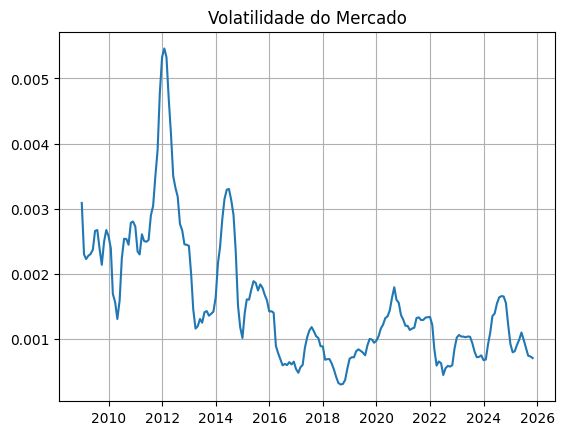

In [ ]:
df['volatilidade'] = df[
    'Variacao mensal de vendas residenciais'
].rolling(12).std()

plt.plot(df['Data'], df['volatilidade'])

plt.title('Volatilidade do Mercado')
plt.grid()
plt.show()

O resultado da volatilidade evidencia períodos de maior instabilidade no mercado.

# Pré-Processamento

O pré-processamento realizado a fim de garantir consistência e qualidade dos dados.

* *fillna*

  Foram identificados valores faltantes no dataset, especialmente nos períodos iniciais da série temporal. Para tratá-los, foi utilizado o método forward fill (ffill), que propaga o último valor válido conhecido. Essa abordagem é adequada para dados temporais, pois preserva a continuidade da série sem introduzir distorções significativas.

  Sendo assim, métodos como média ou mediana não foram utilizados, pois poderiam descaracterizar o comportamento temporal dos dados.

* Normalização

  Foi aplicada a técnica de normalização para ajustar as variáveis a uma mesma escala. Isso é importante para evitar que atributos com valores maiores tenham influência desproporcional na análise e para permitir comparações mais adequadas entre variáveis, como preços de venda e aluguel.

  Essa técnica também facilita a visualização conjunta de variáveis em gráficos comparativos.

* Criação de variáveis

  Foram criadas novas variáveis a partir dos dados existentes, como o ano extraído da data, com o objetivo de facilitar análises agregadas e identificar padrões ao longo do tempo.

  Essa transformação permitiu analisar tendências anuais, reduzindo a influência de variações mensais.

# Pós-processamento

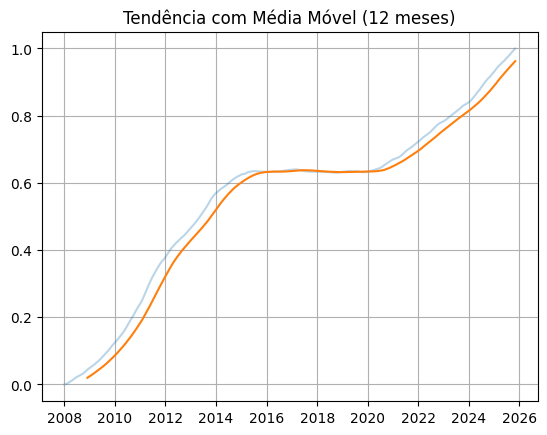

In [ ]:
df['media_movel'] = df[
    'Preco medio de vendas residenciais (RS/m2)'
].rolling(12).mean()

plt.plot(df['Data'], df['Preco medio de vendas residenciais (RS/m2)'], alpha=0.3)
plt.plot(df['Data'], df['media_movel'])

plt.title('Tendência com Média Móvel (12 meses)')
plt.grid()
plt.show()

Após o tratamento, a tendência se torna mais clara e consistente.

# Insights

O mercado imobiliário apresenta crescimento no longo prazo, com os preços de venda e aluguel evoluindo de forma semelhante. No entanto, a rentabilidade não acompanha esse crescimento de maneira linear, apresentando oscilações ao longo do tempo. Esse comportamento evidencia que o mercado é dinâmico e cíclico, com períodos de valorização e desaceleração.

# Tratamento de valores faltantes

In [ ]:
df.ffill(inplace=True)

Os valores faltantes foram tratados utilizando o método forward fill (ffill), apropriado para séries temporais, pois preserva a continuidade dos dados ao propagar o último valor válido.

# Criação de variáveis

In [ ]:
df['Ano'] = df['Data'].dt.year

# Normalização

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

colunas = [
    'Preco medio de vendas residenciais (RS/m2)',
    'Preco medio de alugueis residenciais (RS/m2)'
]

df[colunas] = scaler.fit_transform(df[colunas])

# Respondendo as hipóteses


**1. Os preços aumentam ao longo do tempo?**

Sim. Observa-se uma tendência ao crescimento nos preços de venda e aluguel ao longo dos anos.

**2. Existe correlação entre venda e aluguel?**

Sim. Os preços apresentam comportamento semelhante, indicando correlação positiva.

**3. A rentabilidade acompanha os preços?**

Tudo indica que nem sempre. A rentabilidade apresenta oscilações e não cresce na mesma proporção.


# Conclusão

A análise do dataset FipeZap demonstrou que o mercado imobiliário brasileiro apresenta tendência de valorização ao longo do tempo, com crescimento consistente dos preços de venda e aluguel.

Entretanto, a rentabilidade dos aluguéis não acompanha necessariamente esse crescimento, indicando que o aumento dos preços não garante maior retorno ao investidor.

Em tempo, a análise exploratória evidenciou relações importantes entre as variáveis e destacou a importância do pré-processamento para garantir a qualidade dos dados.

Por fim, as hipóteses levantadas foram parcialmente confirmadas, reforçando a complexidade do comportamento do mercado imobiliário.